# Agente v140 en pendientes

Resultados de `slope_test.py` (100M @ 1.40 m/s). La pendiente se aplica inclinando la gravedad en un mundo plano; la política no percibe la pendiente. Caída = terminación por defecto del entorno.

Para regenerar los datos: `python pruebas_pendiente/slope_test.py --angles 0 5 10 15 20 25 30 40`.

In [2]:
import numpy as np
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

path = Path('slope_results.json')
if not path.exists():
    path = Path('pruebas_pendiente/slope_results.json')
df = pd.DataFrame(json.loads(path.read_text()))
df['signed'] = df.apply(lambda r: r.angle if r['mode'] == 'up' else -r.angle, axis=1)
df = df.sort_values('signed')
df[['mode','angle','fall_frac','t_fall_median','t_fall_min','survive_s','vx_mean']]

,mode,angle,fall_frac,t_fall_median,t_fall_min,survive_s,vx_mean
14,down,40.0,0.96875,2.740,1.25,2.978125,3.100073
13,down,30.0,0.15625,4.710,2.49,8.374063,2.512869
12,down,25.0,0.00000,NaN,NaN,9.000000,2.338706
11,down,20.0,0.00000,NaN,NaN,9.000000,2.133705
10,down,15.0,0.00000,NaN,NaN,9.000000,1.965741
9,down,10.0,0.00000,NaN,NaN,9.000000,1.784442
8,down,5.0,0.00000,NaN,NaN,9.000000,1.599707
0,up,0.0,0.00000,NaN,NaN,9.000000,1.392762
1,up,5.0,0.00000,NaN,NaN,9.000000,1.173720
2,up,10.0,0.00000,NaN,NaN,9.000000,0.958757


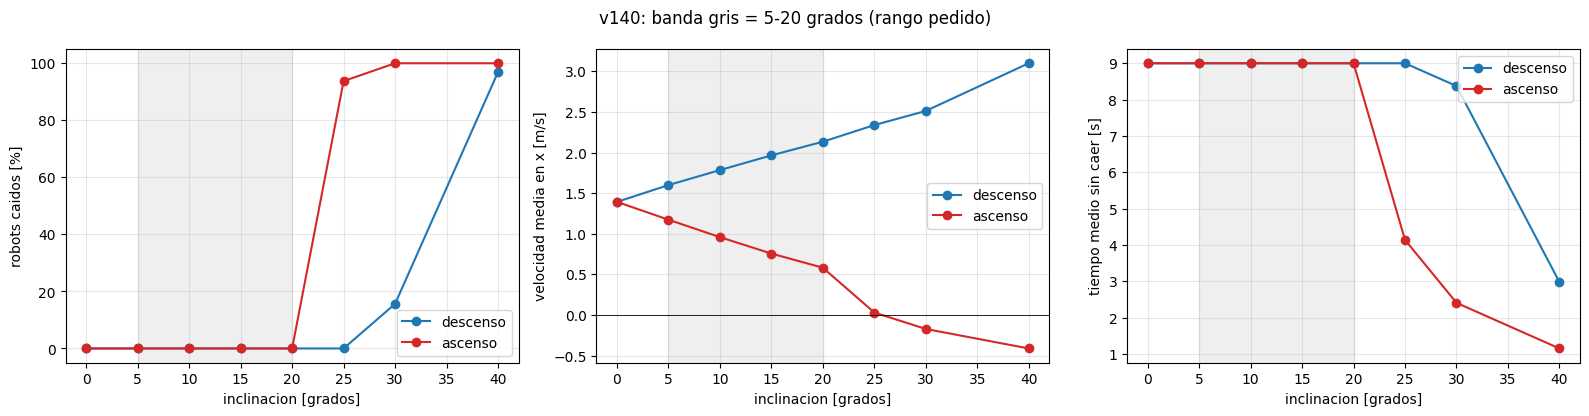

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
cols = {'up': 'tab:red', 'down': 'tab:blue'}
names = {'up': 'ascenso', 'down': 'descenso'}
ref = df[df.angle == 0].iloc[0]
for mode, g in df.groupby('mode'):
    g = pd.concat([g, ref.to_frame().T]).drop_duplicates(['angle']).sort_values('angle') if mode == 'down' else g.sort_values('angle')
    ax[0].plot(g.angle, 100*g.fall_frac, 'o-', c=cols[mode], label=names[mode])
    ax[1].plot(g.angle, g.vx_mean, 'o-', c=cols[mode], label=names[mode])
    ax[2].plot(g.angle, g.survive_s, 'o-', c=cols[mode], label=names[mode])
ax[0].set_ylabel('robots caidos [%]'); ax[1].set_ylabel('velocidad media en x [m/s]'); ax[2].set_ylabel('tiempo medio sin caer [s]')
ax[1].axhline(0, c='k', lw=.6)
for a in ax:
    a.axvspan(5, 20, color='gray', alpha=.12); a.set_xlabel('inclinacion [grados]'); a.grid(alpha=.3); a.legend()
fig.suptitle('v140: banda gris = 5-20 grados (rango pedido)')
plt.tight_layout(); plt.show()

**Lectura:** sin caídas hasta 20° en ambos sentidos. El límite en ascenso está entre 20° y 25° (el robot pierde empuje y retrocede) y en descenso entre 25° y 30° (acelera demasiado).

## Videos
El suelo se ve inclinado (el mundo se gira para dejar la gravedad vertical). El robot avanza hacia la derecha; ascenso = sube. Se generan con `render_slopes.py`; el video se corta 0.5 s despues de una caida.

In [4]:
from IPython.display import HTML, display
vdir = path.parent / 'videos'
cases = [f'{m}_{a}' for m in ('up','down') for a in (5,10,15,20)] + ['up_25','down_30']
cards = ''.join(
    f'<div style="display:inline-block;margin:4px"><b>{c.replace("up","ascenso").replace("down","descenso").replace("_"," ")}&deg;</b><br>'
    f'<video src="{(vdir/(c+".mp4")).as_posix()}" width="420" controls loop muted></video></div>'
    for c in cases if (vdir/(c+'.mp4')).exists())
display(HTML(cards))


## Diagnostico del limite

`slope_diagnosis.py`: friccion x1/x2/x4 (v140), agente v0218, saturacion de actuadores (|accion| >= 0.98; ctrlrange +-80 N.m cadera/rodilla, +-40 tobillo) y modo de caida (cabeceo + = nariz abajo, respecto a la pendiente).

In [5]:
dg = pd.DataFrame(json.loads((path.parent / 'slope_diagnosis.json').read_text()))
dg['caso'] = dg['mode'].map({'up': 'sube', 'down': 'baja'}) + ' ' + dg.angle.astype(int).astype(str)
dg['variante'] = dg.agent + ' mu x' + dg.mu.astype(int).astype(str)
cols = ['fall_frac', 't_fall_median', 'vx_mean', 'sat_hip', 'sat_knee', 'sat_ankle', 'fall_pitch_deg', 'fall_abs_roll_deg', 'fall_height_m']
display(dg.pivot(index='caso', columns='variante', values='fall_frac').mul(100).round(0).rename_axis(columns='% caidas'))
dg[['variante', 'caso'] + cols].round(2)

% caidas,v0218 mu x1,v140 mu x1,v140 mu x2,v140 mu x4
caso,,,,
baja 25,100.0,0.0,100.0,100.0
baja 30,100.0,12.0,100.0,100.0
baja 35,100.0,94.0,100.0,100.0
baja 40,100.0,100.0,100.0,100.0
sube 20,9.0,0.0,0.0,0.0
sube 25,100.0,88.0,19.0,0.0
sube 30,100.0,100.0,100.0,100.0


,variante,caso,fall_frac,t_fall_median,vx_mean,sat_hip,sat_knee,sat_ankle,fall_pitch_deg,fall_abs_roll_deg,fall_height_m
0,v140 mu x1,sube 20,0.00,NaN,0.58,0.0,0.0,0.0,NaN,NaN,NaN
1,v140 mu x1,sube 25,0.88,3.80,0.03,0.0,0.0,0.0,-1.88,17.28,0.30
2,v140 mu x1,sube 30,1.00,2.03,-0.13,0.0,0.0,0.0,-10.94,19.19,0.29
3,v140 mu x1,baja 25,0.00,NaN,2.34,0.0,0.0,0.0,NaN,NaN,NaN
4,v140 mu x1,baja 30,0.12,5.99,2.51,0.0,0.0,0.0,24.44,6.88,0.29
5,v140 mu x1,baja 35,0.94,3.02,2.72,0.0,0.0,0.0,18.96,14.98,0.30
6,v140 mu x1,baja 40,1.00,2.66,3.10,0.0,0.0,0.0,2.68,15.45,0.34
7,v140 mu x2,sube 20,0.00,NaN,0.58,0.0,0.0,0.0,NaN,NaN,NaN
8,v140 mu x2,sube 25,0.19,5.86,0.31,0.0,0.0,0.0,-22.38,10.60,0.31
9,v140 mu x2,sube 30,1.00,2.55,-0.07,0.0,0.0,0.0,-27.23,7.44,0.33


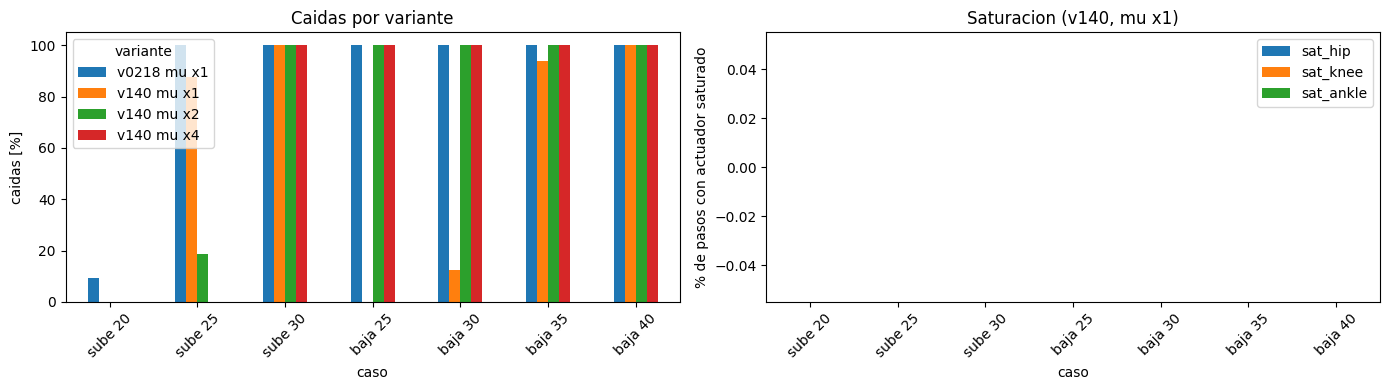

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
order = list(dict.fromkeys(dg.caso))
dg.pivot(index='caso', columns='variante', values='fall_frac').loc[order].mul(100).plot.bar(ax=ax[0], rot=45)
ax[0].set_ylabel('caidas [%]'); ax[0].set_title('Caidas por variante')
b = dg[(dg.agent == 'v140') & (dg.mu == 1)].set_index('caso').loc[order]
b[['sat_hip', 'sat_knee', 'sat_ankle']].mul(100).plot.bar(ax=ax[1], rot=45)
ax[1].set_ylabel('% de pasos con actuador saturado'); ax[1].set_title('Saturacion (v140, mu x1)')
plt.tight_layout(); plt.show()

## Comparacion entre agentes

Carga todos los `slope_results*.json`: v140 (`slope_results.json`) y cada agente evaluado con
`python pruebas_pendiente/slope_test.py --agent <ruta a PPOJax_saved.pkl> --angles 0 5 10 15 20 25 30 35`.
Cada agente usa por defecto su propio criterio de caida (v140: tronco a >30 grados de la postura de la
referencia; ajuste fino con recompensa de tarea: tronco a >50 grados de la vertical). Para compararlos con
la misma vara, evaluar todos con `--fall upright` (o `--fall reference`). Eje x: pendiente con signo (+ sube, - baja).

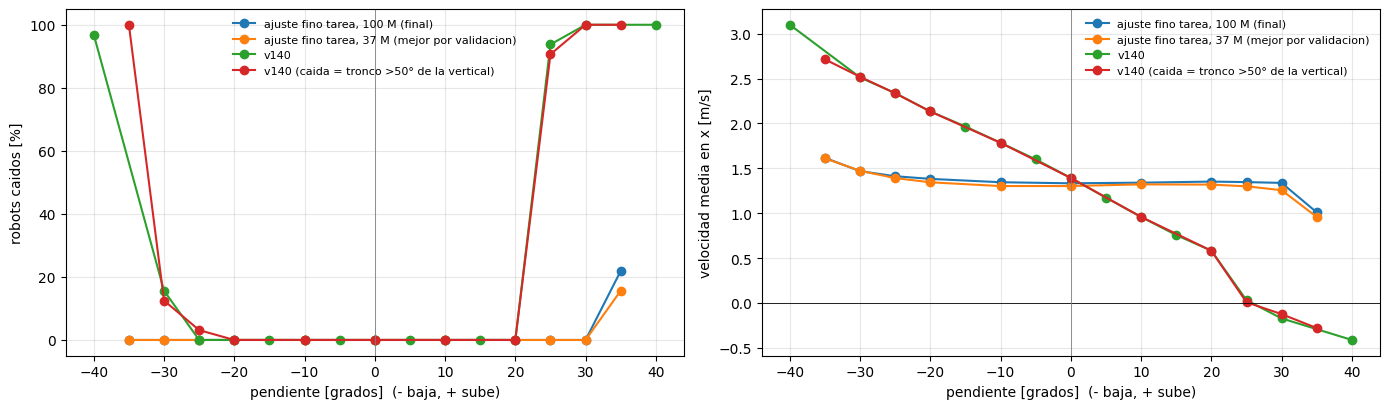

% caidas,"ajuste fino tarea, 100 M (final)","ajuste fino tarea, 37 M (mejor por validacion)",v140,v140 (caida = tronco >50° de la vertical)
signed,,,,
-40.0,NaN,NaN,97.0,NaN
-35.0,0.0,0.0,NaN,100.0
-30.0,0.0,0.0,16.0,12.0
-25.0,0.0,0.0,0.0,3.0
-20.0,0.0,0.0,0.0,0.0
-15.0,NaN,NaN,0.0,NaN
-10.0,0.0,0.0,0.0,0.0
-5.0,NaN,NaN,0.0,NaN
0.0,0.0,0.0,0.0,0.0


In [7]:
frames = []
for f in sorted(path.parent.glob('slope_results*.json')):
    d = pd.DataFrame(json.loads(f.read_text()))
    if 'agent' not in d:
        d['agent'] = 'v140'
    d['agent'] = d['agent'] + (' (via randomizer)' if '_via_randomizer' in f.stem else '')
    if 'fall_criterion' in d:
        d['agent'] = d['agent'] + d['fall_criterion'].map(lambda c: '' if c == 'agent' else f' [caida: {c}]')
    frames.append(d)
AGENT_NAMES = {'v140': 'v140',
               'v140 [caida: upright]': 'v140 (caida = tronco >50° de la vertical)',
               '2026-09-29_18-49-47': 'ajuste fino tarea, 37 M (mejor por validacion)',
               '2026-09-29_18-49-47_final': 'ajuste fino tarea, 100 M (final)'}
cmp_df = pd.concat(frames, ignore_index=True)
cmp_df['agent'] = cmp_df['agent'].map(lambda a: AGENT_NAMES.get(a, a))
cmp_df['signed'] = np.where(cmp_df['mode'] == 'up', cmp_df.angle, -cmp_df.angle)
cmp_df = cmp_df.drop_duplicates(['agent', 'signed']).sort_values(['agent', 'signed'])

fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
for agent, g in cmp_df.groupby('agent'):
    ax[0].plot(g.signed, 100 * g.fall_frac, 'o-', label=agent)
    ax[1].plot(g.signed, g.vx_mean, 'o-', label=agent)
ax[0].set_ylabel('robots caidos [%]'); ax[1].set_ylabel('velocidad media en x [m/s]')
ax[1].axhline(0, c='k', lw=.6)
for a in ax:
    a.axvline(0, c='gray', lw=.6); a.set_xlabel('pendiente [grados]  (- baja, + sube)'); a.grid(alpha=.3)
ax[0].legend(loc='upper center', fontsize=8, frameon=False); ax[1].legend(loc='upper right', fontsize=8, frameon=False)
plt.tight_layout(); plt.show()
cmp_df.pivot(index='signed', columns='agent', values='fall_frac').mul(100).round(0).rename_axis(columns='% caidas')

## Marcha de v140 por inclinacion (sin ajuste fino)

Datos de `python pruebas_pendiente/gait_by_slope.py` (32 robots, 6 s por pendiente, se descarta el primer
segundo y todo lo posterior a una caida). Un ciclo de marcha va de un aterrizaje de la pata delantera derecha
(FR) al siguiente. Una pata esta apoyada cuando su esfera toca el suelo (centro a <= 2.7 cm) y hasta que sube
de 3.7 cm. Pendiente con signo: **+ sube, - baja**. Colores: azul = bajada, gris = plano, rojo = subida
(mas oscuro = mas empinado).

In [8]:
import matplotlib as mpl
g = np.load(path.parent / 'gait_by_slope.npz', allow_pickle=True)
angles = [int(a) for a in g['angles']]
metric_names = list(g['metrics'])
SLOPE_COLORS = {-20: '#184f95', -15: '#2a78d6', -10: '#5598e7', -5: '#86b6ef', 0: '#52514e',
                5: '#fe8d85', 10: '#f45956', 15: '#d2383a', 20: '#980c1a'}   # divergente: bajada azul, subida rojo
FOOT_COLORS = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100']                  # FR, FL, BR, BL (categoricos 1-4)
FOOT_LABELS = ['del. der. (FR)', 'del. izq. (FL)', 'tras. der. (BR)', 'tras. izq. (BL)']
INK, INK2, MUTED, GRID = '#0b0b0b', '#52514e', '#898781', '#e1e0d9'
mpl.rcParams.update({'axes.edgecolor': '#c3c2b7', 'axes.labelcolor': INK2, 'xtick.color': MUTED, 'ytick.color': MUTED,
                     'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.6, 'axes.spines.top': False,
                     'axes.spines.right': False, 'lines.linewidth': 1.6, 'figure.facecolor': '#fcfcfb',
                     'axes.facecolor': '#fcfcfb', 'axes.titlecolor': INK, 'axes.titlesize': 10})
rows = {a: pd.DataFrame(g[f's{a:+d}_metrics'], columns=metric_names) for a in angles}
summary = pd.DataFrame({a: r.median() for a, r in rows.items()}).T
summary['cadence_hz'] = 1 / summary['period_s']
summary['n_ciclos'] = [len(rows[a]) for a in angles]
summary['caidas_%'] = [100 * float(g[f's{a:+d}_fall_frac']) for a in angles]
summary.index.name = 'pendiente [grados]'
summary[['n_ciclos', 'caidas_%', 'speed_mps', 'period_s', 'cadence_hz', 'stride_m', 'duty_fr', 'duty_fl', 'duty_br',
         'duty_bl', 'pitch_ground_deg', 'pitch_horizontal_deg', 'height_m', 'power_W', 'cot']].round(3)

,n_ciclos,caidas_%,speed_mps,period_s,cadence_hz,stride_m,duty_fr,duty_fl,duty_br,duty_bl,pitch_ground_deg,pitch_horizontal_deg,height_m,power_W,cot
pendiente [grados],,,,,,,,,,,,,,,
-20,218,0.0,2.153,0.630,1.587,1.360,0.190,0.222,0.460,0.365,-0.123,-20.123,0.367,214.288,1.293
-15,217,0.0,1.983,0.630,1.587,1.250,0.190,0.222,0.444,0.381,0.027,-14.973,0.365,215.720,1.414
-10,216,0.0,1.794,0.635,1.575,1.141,0.203,0.206,0.359,0.413,0.039,-9.961,0.363,214.923,1.558
-5,217,0.0,1.606,0.630,1.587,1.014,0.188,0.190,0.365,0.429,0.218,-4.782,0.364,199.957,1.620
0,217,0.0,1.393,0.640,1.562,0.888,0.175,0.188,0.359,0.469,0.093,0.093,0.363,189.645,1.774
5,218,0.0,1.167,0.635,1.575,0.743,0.172,0.175,0.359,0.469,-0.092,4.908,0.361,180.208,2.011
10,218,0.0,0.946,0.635,1.575,0.600,0.159,0.159,0.375,0.469,-0.268,9.732,0.359,174.876,2.408
15,218,0.0,0.739,0.630,1.587,0.469,0.159,0.156,0.381,0.460,-0.527,14.473,0.358,176.980,3.123
20,219,0.0,0.564,0.630,1.587,0.359,0.156,0.127,0.422,0.492,-0.735,19.265,0.355,182.038,4.192


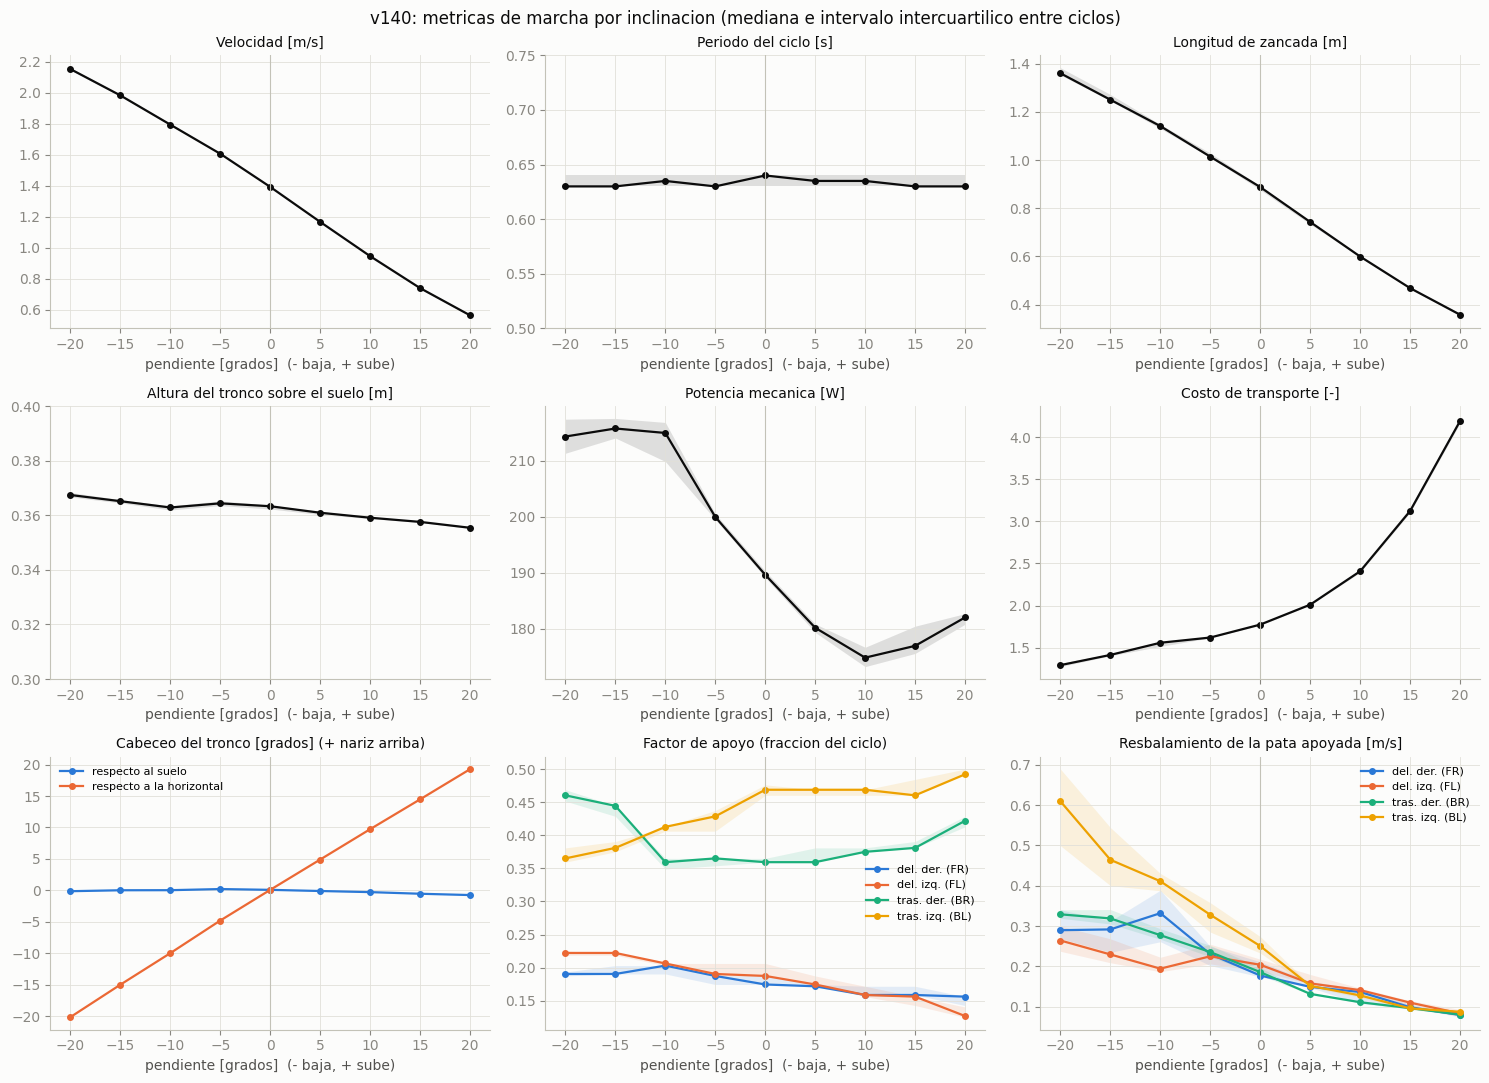

In [9]:
def band(ax, col, color=INK, label=None):
    med = np.array([rows[a][col].median() for a in angles])
    q1 = np.array([rows[a][col].quantile(.25) for a in angles]); q3 = np.array([rows[a][col].quantile(.75) for a in angles])
    ax.fill_between(angles, q1, q3, color=color, alpha=.12, lw=0)
    ax.plot(angles, med, '-o', color=color, ms=4, label=label)

panels = [('speed_mps', 'Velocidad [m/s]'), ('period_s', 'Periodo del ciclo [s]'), ('stride_m', 'Longitud de zancada [m]'),
          ('height_m', 'Altura del tronco sobre el suelo [m]'), ('power_W', 'Potencia mecanica [W]'), ('cot', 'Costo de transporte [-]')]
fig, axs = plt.subplots(3, 3, figsize=(15, 11))
YLIM = {'period_s': (0.5, 0.75), 'height_m': (0.30, 0.40)}   # escala honesta: varian ~1-2 %
for ax, (col, title) in zip(axs.flat, panels):
    band(ax, col); ax.set_title(title)
    if col in YLIM:
        ax.set_ylim(*YLIM[col])
ax = axs.flat[6]
band(ax, 'pitch_ground_deg', FOOT_COLORS[0], 'respecto al suelo')
band(ax, 'pitch_horizontal_deg', FOOT_COLORS[1], 'respecto a la horizontal')
ax.set_title('Cabeceo del tronco [grados] (+ nariz arriba)'); ax.legend(frameon=False, fontsize=8)
for ax, prefix, title in ((axs.flat[7], 'duty', 'Factor de apoyo (fraccion del ciclo)'),
                          (axs.flat[8], 'slip', 'Resbalamiento de la pata apoyada [m/s]')):
    for i, f in enumerate(['fr', 'fl', 'br', 'bl']):
        col = f'{prefix}_{f}' if prefix == 'duty' else f'slip_{f}_mps'
        band(ax, col, FOOT_COLORS[i], FOOT_LABELS[i])
    ax.set_title(title); ax.legend(frameon=False, fontsize=8)
for ax in axs.flat:
    ax.axvline(0, color='#c3c2b7', lw=.8); ax.set_xlabel('pendiente [grados]  (- baja, + sube)'); ax.set_xticks(angles)
fig.suptitle('v140: metricas de marcha por inclinacion (mediana e intervalo intercuartilico entre ciclos)', color=INK)
plt.tight_layout(); plt.show()

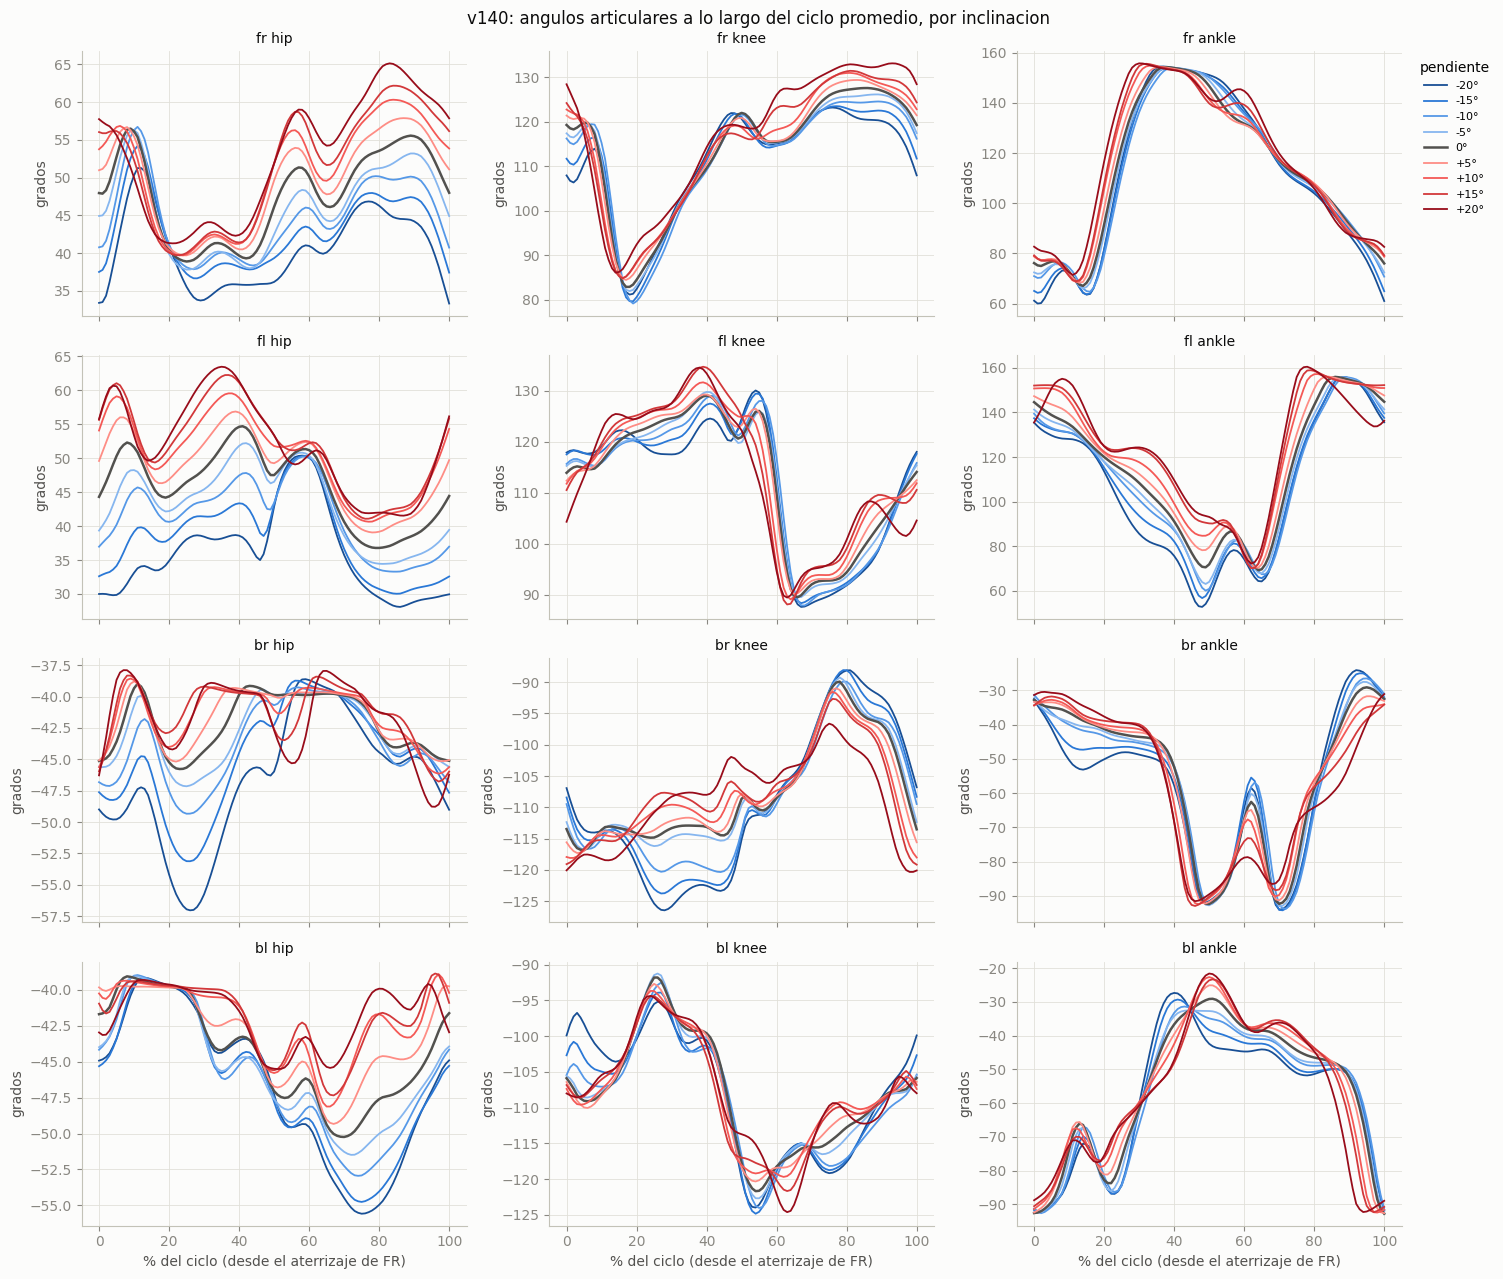

In [10]:
joints = list(g['joints']); phase = np.linspace(0, 100, 101)
fig, axs = plt.subplots(4, 3, figsize=(15, 13), sharex=True)
for k, ax in enumerate(axs.flat):
    for a in angles:
        ax.plot(phase, g[f's{a:+d}_joint_mean'][:, k], color=SLOPE_COLORS[a], lw=1.8 if a == 0 else 1.3,
                label=f'{a:+d}°' if a else '0°')
    ax.set_title(joints[k].replace('_', ' ')); ax.set_ylabel('grados')
for ax in axs[-1]:
    ax.set_xlabel('% del ciclo (desde el aterrizaje de FR)')
axs[0, 2].legend(title='pendiente', frameon=False, fontsize=8, ncol=1, bbox_to_anchor=(1.02, 1), loc='upper left')
fig.suptitle('v140: angulos articulares a lo largo del ciclo promedio, por inclinacion', color=INK)
plt.tight_layout(); plt.show()

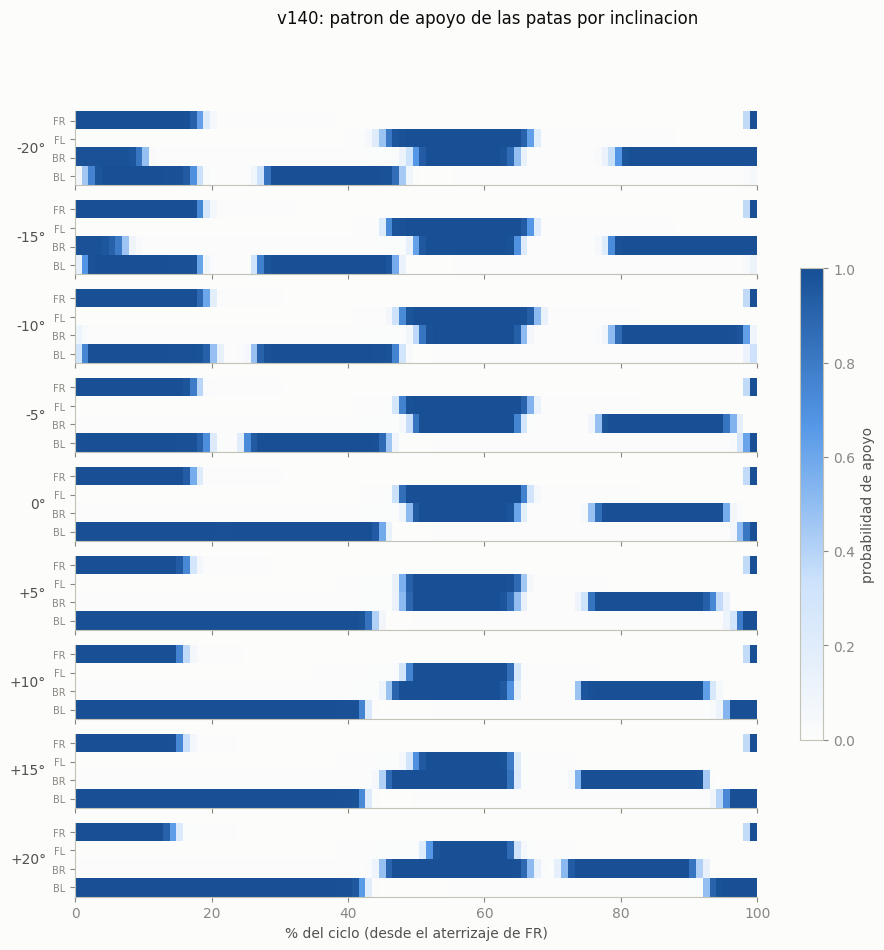

In [11]:
fig, axs = plt.subplots(len(angles), 1, figsize=(11, 1.0 * len(angles) + 1.2), sharex=True)
cmap = mpl.colors.LinearSegmentedColormap.from_list('stance', ['#fcfcfb', '#cde2fb', '#5598e7', '#184f95'])
for ax, a in zip(axs, angles):
    im = ax.imshow(g[f's{a:+d}_contact_mean'].T, aspect='auto', cmap=cmap, vmin=0, vmax=1,
                   extent=[0, 100, 3.5, -0.5], interpolation='nearest')
    ax.set_yticks(range(4)); ax.set_yticklabels(['FR', 'FL', 'BR', 'BL'], fontsize=7); ax.grid(False)
    ax.set_ylabel(f'{a:+d}°' if a else '0°', rotation=0, ha='right', va='center', color=INK2, fontsize=10)
axs[-1].set_xlabel('% del ciclo (desde el aterrizaje de FR)')
fig.colorbar(im, ax=axs, shrink=.6, label='probabilidad de apoyo')
fig.suptitle('v140: patron de apoyo de las patas por inclinacion', color=INK)
plt.show()

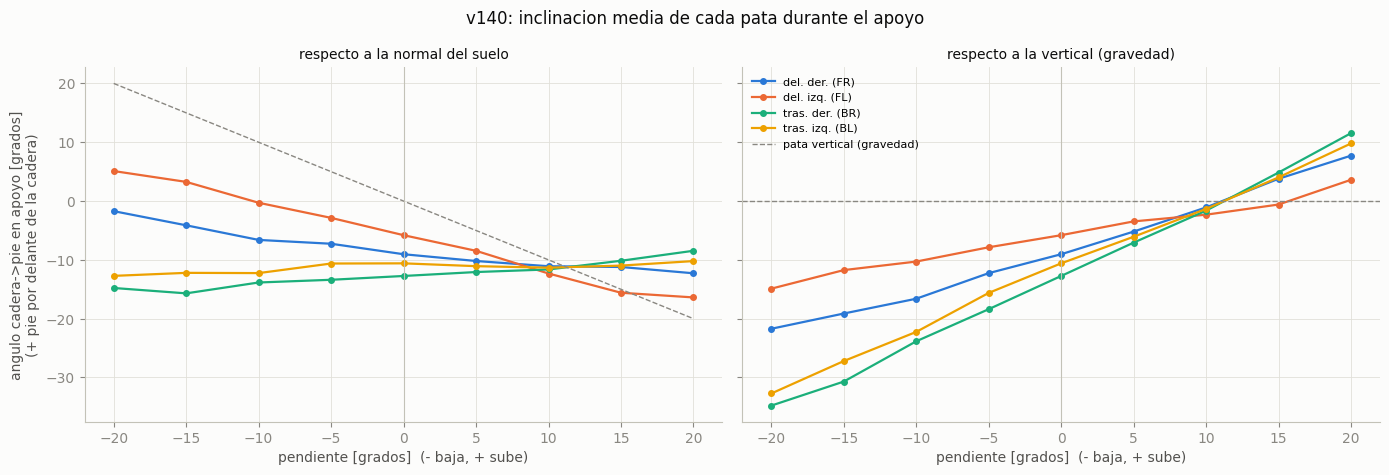

,FR (sup.),FL (sup.),BR (sup.),BL (sup.)
-20,-1.7,5.1,-14.8,-12.7
-15,-4.1,3.3,-15.7,-12.2
-10,-6.6,-0.3,-13.8,-12.2
-5,-7.3,-2.9,-13.4,-10.6
0,-9.0,-5.8,-12.7,-10.6
5,-10.2,-8.5,-12.1,-11.1
10,-11.1,-12.3,-11.6,-11.3
15,-11.2,-15.6,-10.2,-11.0
20,-12.3,-16.4,-8.5,-10.2


In [12]:
import mujoco
xml = path.resolve().parent.parent / 'seneca_loco' / 'simulation' / 'assets' / 'xml' / 'senecabot_loco.xml'
m = mujoco.MjModel.from_xml_path(str(xml)); d = mujoco.MjData(m)
adr = [m.jnt_qposadr[m.joint(f'{j}_joint').id] for j in joints]
legs = ['fr', 'fl', 'br', 'bl']
hip_ids = [m.body(f'{l}_upper').id for l in legs]; foot_ids = [m.site(f'{l}_foot').id for l in legs]
leg_angle = {}   # angulo medio cadera->pie durante el apoyo, respecto a la normal del suelo (+ pie por delante)
for a in angles:
    q, c = g[f's{a:+d}_joint_mean'], g[f's{a:+d}_contact_mean']
    phi = np.zeros((len(q), 4))
    for t in range(len(q)):
        d.qpos[:] = 0; d.qpos[2] = 0.363; d.qpos[3] = 1.0; d.qpos[adr] = np.deg2rad(q[t])
        mujoco.mj_kinematics(m, d)
        for i in range(4):
            v = d.site_xpos[foot_ids[i]] - d.xpos[hip_ids[i]]
            phi[t, i] = np.degrees(np.arctan2(v[0], -v[2]))
    leg_angle[a] = [phi[c[:, i] > 0.5, i].mean() for i in range(4)]
s = np.array(angles, float)
fig, axs = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
for i in range(4):
    sup = np.array([leg_angle[a][i] for a in angles])
    axs[0].plot(angles, sup, '-o', ms=4, color=FOOT_COLORS[i], label=FOOT_LABELS[i])
    axs[1].plot(angles, sup + s, '-o', ms=4, color=FOOT_COLORS[i], label=FOOT_LABELS[i])
axs[0].plot(angles, -s, '--', color=MUTED, lw=1, label='pata vertical (gravedad)')
axs[1].axhline(0, ls='--', color=MUTED, lw=1, label='pata vertical (gravedad)')
axs[0].set_title('respecto a la normal del suelo'); axs[1].set_title('respecto a la vertical (gravedad)')
axs[0].set_ylabel('angulo cadera->pie en apoyo [grados]\n(+ pie por delante de la cadera)')
for ax in axs:
    ax.axvline(0, color='#c3c2b7', lw=.8); ax.set_xticks(angles); ax.set_xlabel('pendiente [grados]  (- baja, + sube)')
axs[1].legend(frameon=False, fontsize=8)
fig.suptitle('v140: inclinacion media de cada pata durante el apoyo', color=INK)
plt.tight_layout(); plt.show()
pd.DataFrame(leg_angle, index=[f'{l.upper()} (sup.)' for l in legs]).T.round(1)

**Lectura (v140, sin ajuste fino).** v140 no cambia su marcha con la pendiente, solo la sufre:

- **Mismo ritmo:** el ciclo dura 0.63-0.64 s en todas las pendientes (va sincronizado con el reloj de la
  referencia que imita). Toda la diferencia de velocidad sale de la zancada: 1.36 m bajando 20 grados y
  0.36 m subiendo 20 grados.
- **Misma postura respecto al suelo:** el tronco va paralelo a la pendiente (cabeceo respecto al suelo
  dentro de +-1 grado) y a la misma altura (+-1 cm). No se agacha ni nivela el tronco.
- **Adaptacion solo en las patas delanteras:** las caderas delanteras cambian su angulo medio 0.3-0.4 grados
  por cada grado de pendiente, y el tobillo delantero izquierdo 0.5; las traseras casi nada (<=0.15).
- **Consecuencia respecto a la gravedad:** al apoyar, bajando 20 grados los pies quedan 15-35 grados detras
  de la cadera (el cuerpo se vuelca hacia adelante, que es el modo de caida al bajar) y subiendo 20 grados
  quedan 4-12 grados por delante (el cuerpo se carga hacia atras).
- **Apoyos y resbalamiento:** al subir se apoyan mas las traseras (BL 49 %) y menos las delanteras (FL 13 %);
  al bajar las patas resbalan mas (BL 0.6 m/s frente a 0.08 m/s subiendo).
- **Energia:** la potencia mecanica casi no cambia (175-215 W), pero el costo de transporte sube de 1.3
  (bajando 20 grados) a 4.2 (subiendo 20 grados) porque avanza mucho menos por ciclo.

## Comparacion de la marcha: v140 frente al ajuste fino con recompensa de tarea

Carga todos los `gait_by_slope*.npz` (v140: `gait_by_slope.npz`; otros agentes:
`python pruebas_pendiente/gait_by_slope.py --agent <ruta a PPOJax_saved.pkl> --angles -30 -25 ... 30`).
Cada agente se evalua con su propio criterio de caida y solo cuentan los ciclos antes de caer. Color = agente.

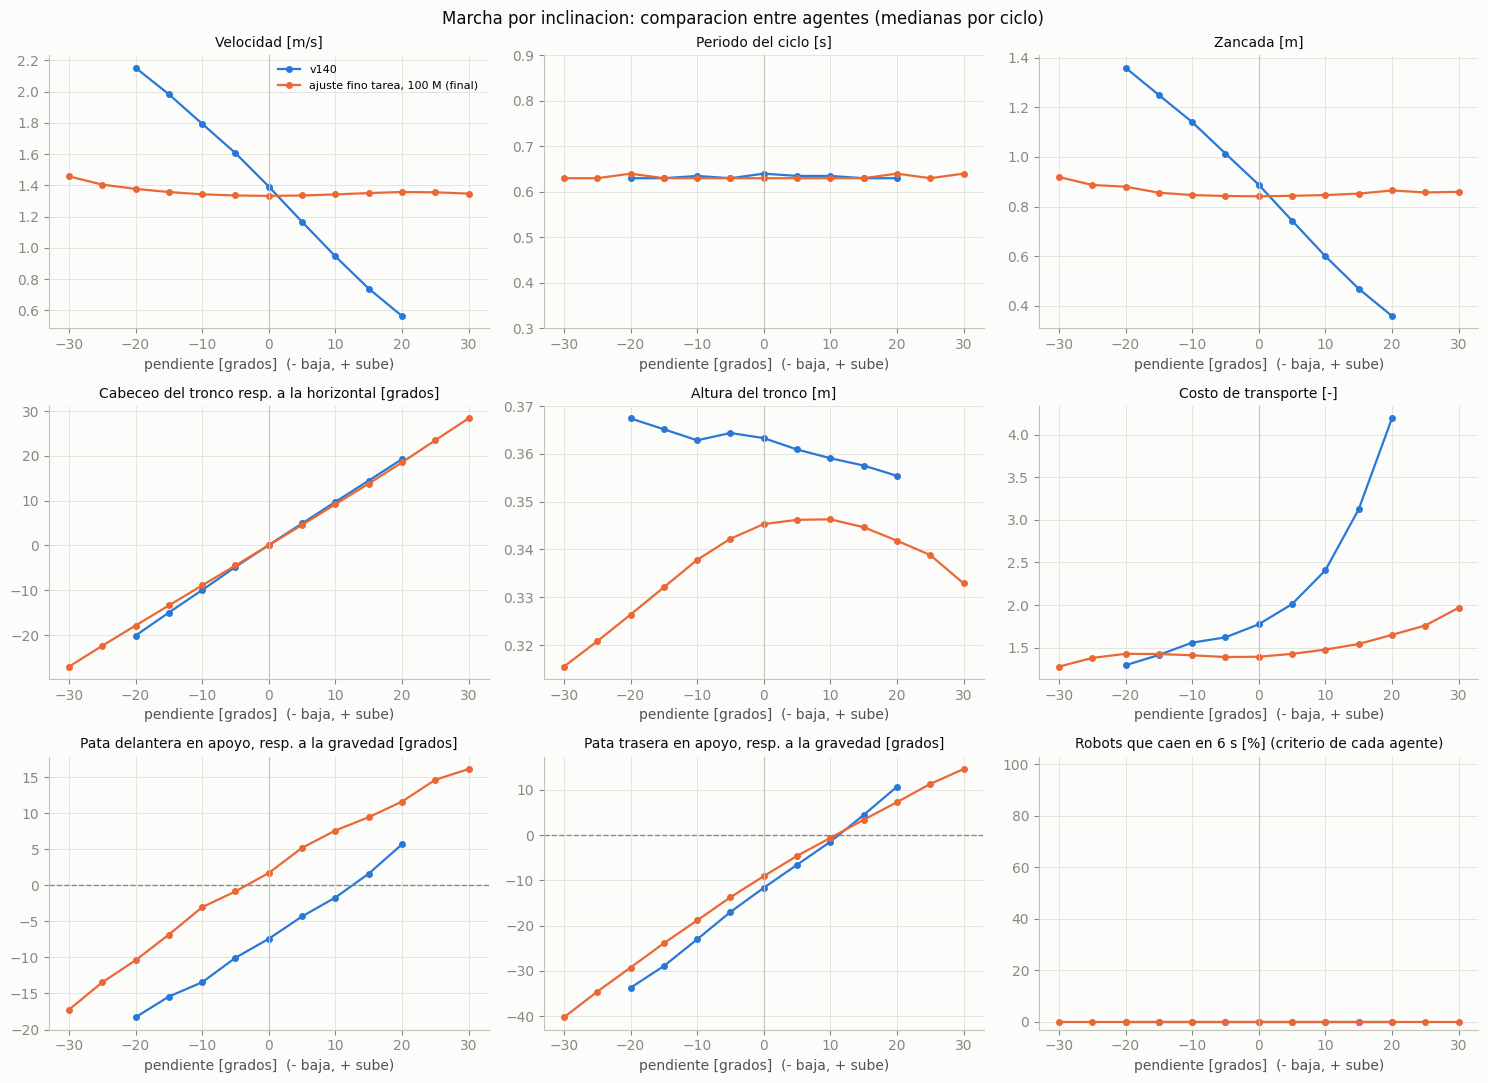

In [13]:
def stance_leg_angles(z, angs):
    # angulo medio cadera->pie durante el apoyo, respecto a la normal del suelo (+ pie por delante)
    out = {}
    for a in angs:
        q, c = z[f's{a:+d}_joint_mean'], z[f's{a:+d}_contact_mean']
        phi = np.zeros((len(q), 4))
        for t in range(len(q)):
            d.qpos[:] = 0; d.qpos[2] = 0.363; d.qpos[3] = 1.0; d.qpos[adr] = np.deg2rad(q[t])
            mujoco.mj_kinematics(m, d)
            for i in range(4):
                v = d.site_xpos[foot_ids[i]] - d.xpos[hip_ids[i]]
                phi[t, i] = np.degrees(np.arctan2(v[0], -v[2]))
        out[a] = [phi[c[:, i] > 0.5, i].mean() if (c[:, i] > 0.5).any() else np.nan for i in range(4)]
    return out

agents = {}
for f in sorted(path.parent.glob('gait_by_slope*.npz')):
    z = np.load(f, allow_pickle=True)
    angs = [int(a) for a in z['angles'] if len(z[f's{int(a):+d}_metrics'])]
    rows_a = {a: pd.DataFrame(z[f's{a:+d}_metrics'], columns=list(z['metrics'])) for a in angs}
    agents[AGENT_NAMES.get(str(z['agent']), str(z['agent']))] = dict(angles=angs, rows=rows_a, legs=stance_leg_angles(z, angs),
                                   falls={a: float(z[f's{a:+d}_fall_frac']) for a in angs})
AGENT_COLORS = dict(zip(agents, ['#2a78d6', '#eb6834', '#1baf7a', '#eda100']))   # categoricos 1-4
if len(agents) < 2:
    print('Solo hay datos de', list(agents), '- falta correr gait_by_slope.py con el agente del ajuste fino.')
else:
    def med(ag, col):
        return np.array([agents[ag]['rows'][a][col].median() for a in agents[ag]['angles']])
    panels = [('speed_mps', 'Velocidad [m/s]'), ('period_s', 'Periodo del ciclo [s]'), ('stride_m', 'Zancada [m]'),
              ('pitch_horizontal_deg', 'Cabeceo del tronco resp. a la horizontal [grados]'),
              ('height_m', 'Altura del tronco [m]'), ('cot', 'Costo de transporte [-]')]
    fig, axs = plt.subplots(3, 3, figsize=(15, 11))
    for ax, (col, title) in zip(axs.flat, panels):
        for ag in agents:
            ax.plot(agents[ag]['angles'], med(ag, col), '-o', ms=4, color=AGENT_COLORS[ag], label=ag)
        ax.set_title(title)
    axs.flat[1].set_ylim(0.3, 0.9)
    for k, (feet, title) in enumerate((([0, 1], 'Pata delantera en apoyo, resp. a la gravedad [grados]'),
                                       ([2, 3], 'Pata trasera en apoyo, resp. a la gravedad [grados]'))):
        ax = axs.flat[6 + k]
        for ag in agents:
            angs = agents[ag]['angles']
            ax.plot(angs, [np.nanmean([agents[ag]['legs'][a][i] for i in feet]) + a for a in angs], '-o', ms=4,
                    color=AGENT_COLORS[ag], label=ag)
        ax.axhline(0, ls='--', color=MUTED, lw=1); ax.set_title(title)
    ax = axs.flat[8]
    for ag in agents:
        angs = agents[ag]['angles']
        ax.plot(angs, [100 * agents[ag]['falls'][a] for a in angs], '-o', ms=4, color=AGENT_COLORS[ag], label=ag)
    ax.set_title('Robots que caen en 6 s [%] (criterio de cada agente)'); ax.set_ylim(-3, 103)
    for ax in axs.flat:
        ax.axvline(0, color='#c3c2b7', lw=.8); ax.set_xlabel('pendiente [grados]  (- baja, + sube)')
    axs.flat[0].legend(frameon=False, fontsize=8)
    fig.suptitle('Marcha por inclinacion: comparacion entre agentes (medianas por ciclo)', color=INK)
    plt.tight_layout(); plt.show()

**Lectura (ajuste fino con recompensa de tarea, checkpoint final de 100 M pasos, `2026-09-29/18-49-47`).**

- **Estabilidad:** aguanta +-30 grados sin caidas. v140 se cae desde 25 grados al subir y a 35 al bajar. A 35
  grados (fuera del rango de entrenamiento) cae el 22 % subiendo y ninguno bajando.
- **Velocidad regulada:** 1.33-1.46 m/s en todas las pendientes (v140: de 2.15 bajando a 0.56 subiendo). Empuja
  mas al subir y frena al bajar, con una zancada casi constante (0.84-0.92 m).
- **Ritmo igual:** el ciclo sigue en 0.63 s, porque la referencia sigue entrando como reloj y nada premia
  cambiar la cadencia.
- **Postura:** baja el tronco en pendiente (3 cm a +-30 grados) y adelanta ~8 grados las patas delanteras
  respecto a v140. Al bajar las apoya menos por detras de la cadera: apuntala en vez de volcarse. El
  tronco sigue casi paralelo a la pendiente.
- **Energia:** el costo de transporte subiendo 20 grados baja de 4.2 (v140) a 1.6.

In [14]:
from IPython.display import HTML, display
vdir = path.resolve().parent / 'videos'
ft = vdir / '2026-09-29_18-49-47_final'
rows_html = ''
for case in ['up_10', 'up_20', 'up_30', 'down_10', 'down_20', 'down_30']:
    name = case.replace('up', 'sube').replace('down', 'baja').replace('_', ' ') + '°'
    cells = ''
    for label, f in (('v140', vdir / f'{case}.mp4'), ('ajuste fino', ft / f'{case}.mp4')):
        cells += (f'<div style="display:inline-block;margin:4px"><b>{name} - {label}</b><br>'
                  + (f'<video src="{f.relative_to(path.resolve().parent).as_posix()}" width="380" controls loop muted></video>'
                     if f.exists() else '<div style="width:380px;height:214px;border:1px dashed #c3c2b7">sin video</div>')
                  + '</div>')
    rows_html += f'<div>{cells}</div>'
display(HTML(rows_html))